In [34]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, curve_fit
from emcee import EnsembleSampler

import matplotlib.pyplot as plt

In [46]:
#read in data, fix columns
df = (pd.read_csv("polarizer_correlation.csv")
      .drop(columns=['Trial Number', 'Angle A'])
      .rename(columns={
          "Angle B": "ANGLE",
          "N_coin / time": "COIN_RATE"
      }))
df

,ANGLE,N_A,N_B,N_COIN,TIME [s],COIN_RATE
0,0.0,NaN,NaN,14340,10.00077,1433.889591
1,22.5,NaN,NaN,13079,9.99107,1309.068999
2,30.0,NaN,NaN,11696,9.99126,1170.623125
3,45.0,NaN,NaN,8637,10.00051,863.655954
4,60.0,NaN,NaN,5221,9.99106,522.567175
5,67.5,NaN,NaN,3204,10.00011,320.396476
6,90.0,NaN,NaN,1333,9.98170,133.544386
7,100.0,NaN,NaN,1651,9.98067,165.419756
8,112.5,NaN,NaN,3362,10.00016,336.194621
9,120.0,NaN,NaN,4630,9.98259,463.807489


In [47]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

In [103]:
def model(x, phase, amplitude, baseline):
    x = np.array(x)
    y = amplitude * np.cos(x * np.pi / 90 + phase * np.pi/180) + baseline
    return y

In [104]:
def redchi2(theta):
    y_mod = model(df["ANGLE"], *theta)
    y_data = df["N_COIN"]
    return np.sum((y_data - y_mod)**2/y_data) / len(df - len(theta))

In [105]:
p0 = [0, 7500, 7500]

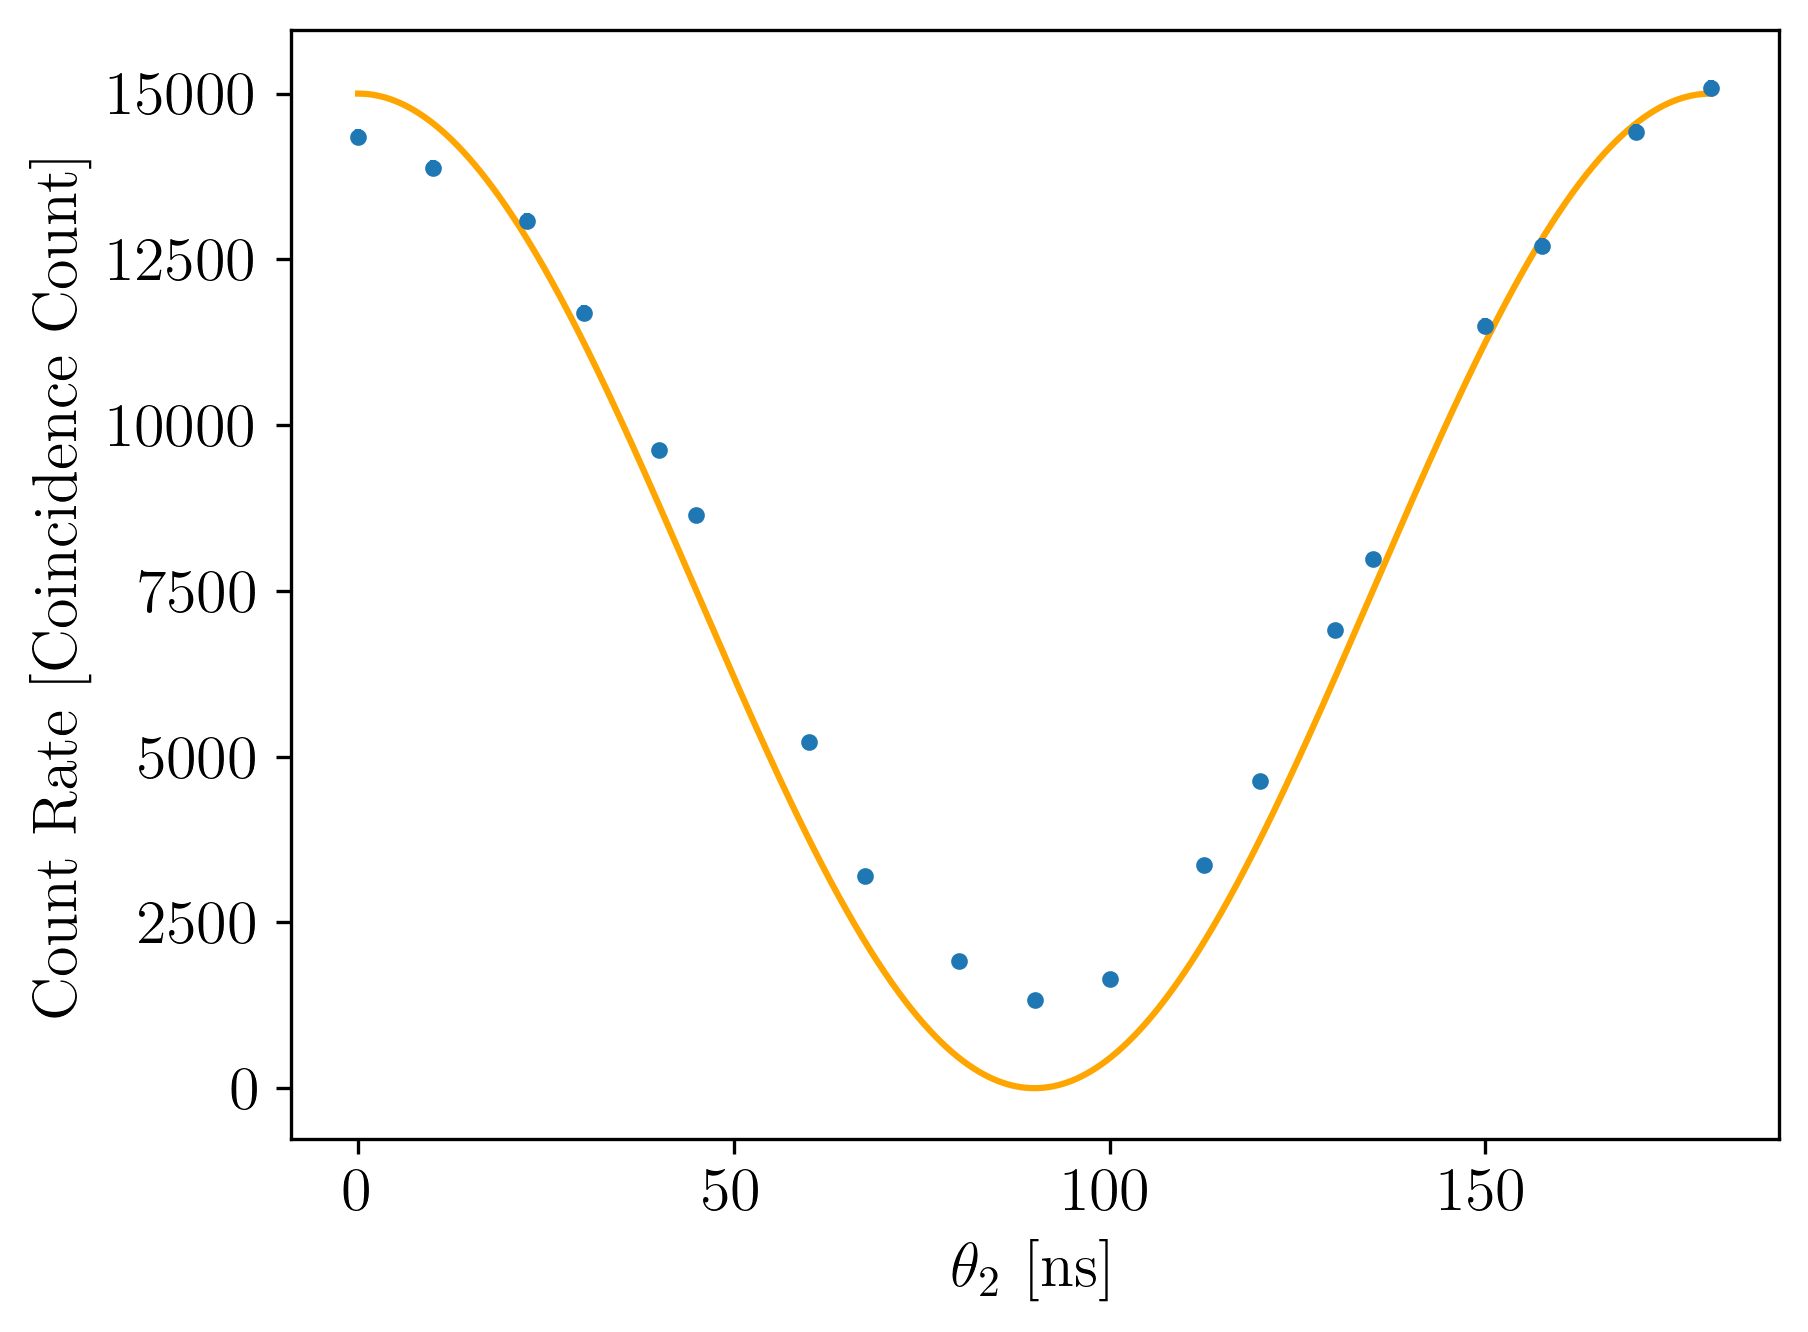

In [108]:
fig, ax = plt.subplots(dpi = 300)

x = np.linspace(0, 180, 5000)
y = model(x, *p0)
ax.plot(x, y, color = "orange")
ax.errorbar(df['ANGLE'], df['N_COIN'], np.sqrt(df['N_COIN']), ls="", marker = ".")
ax.set_xlabel("$\\theta_2$ [ns]")
ax.set_ylabel("Count Rate $[\\text{Coincidence Count}]$")
plt.savefig("tau_fit.png")

In [109]:
# opt_res = minimize(lambda p: redchi2(np.exp(p)), np.log(p0), method="Nelder-Mead")
# tau_fit = np.exp(opt_res.x)[0]
# width_fit = np.exp(opt_res.x)[1]
# opt_res

In [110]:
pcurve_fit, ecurve_fit = curve_fit(model, df['ANGLE'], df['N_COIN'], p0)
ecurve_fit

array([[ 5.22713323e-01,  2.14701962e+00, -2.04245303e-01],
       [ 2.14701962e+00,  6.94012344e+03, -3.65495823e+02],
       [-2.04245303e-01, -3.65495823e+02,  3.50650308e+03]])

In [111]:
pcurve_fit

array([-1.63540797e+00,  6.66186259e+03,  8.13215005e+03])

In [115]:
np.sqrt((np.diag(ecurve_fit)))

array([ 0.72298916, 83.30740326, 59.21573341])

In [116]:
redchi2(pcurve_fit)

np.float64(7.8068928542053255)

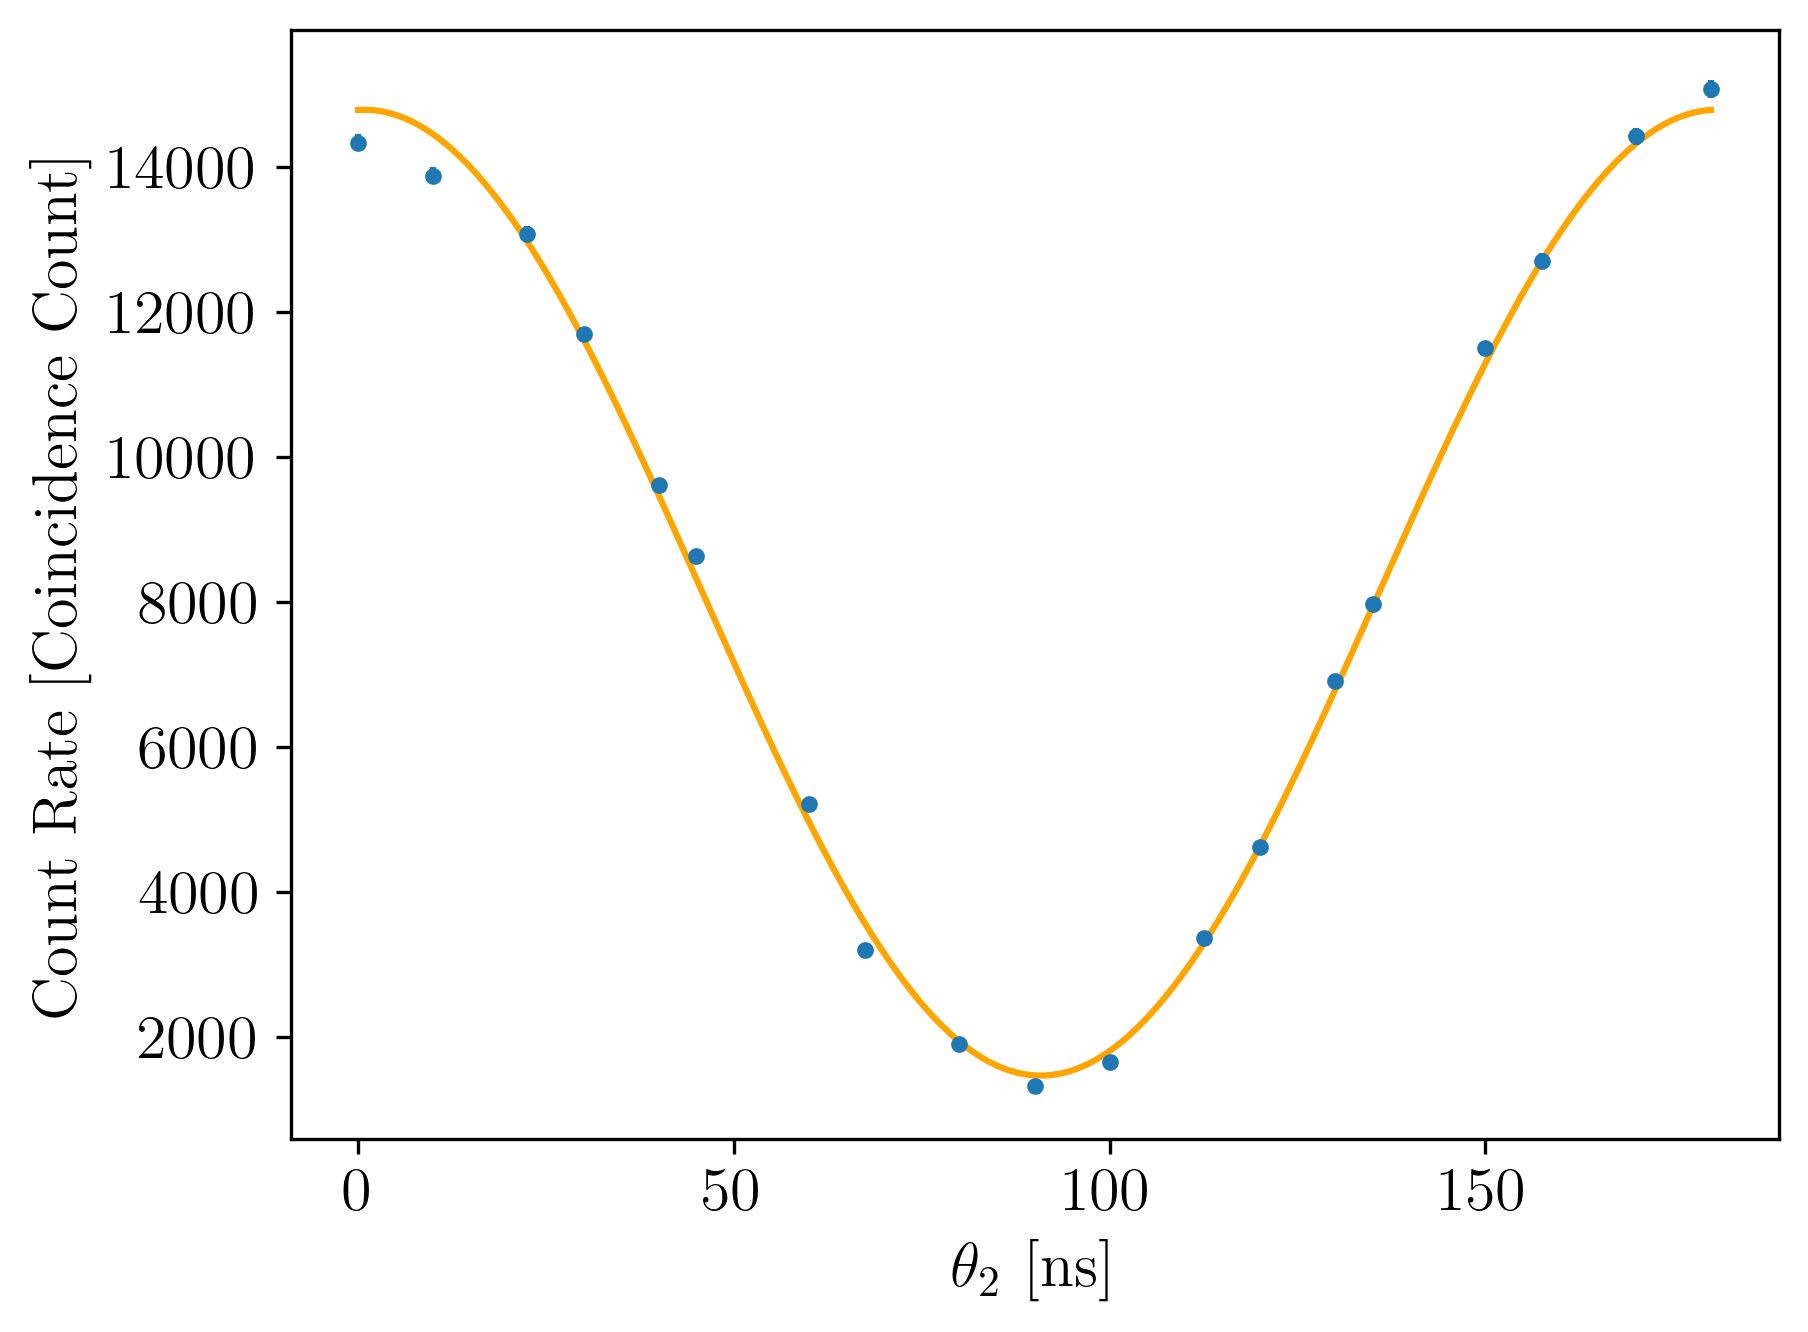

In [113]:
fig, ax = plt.subplots(dpi = 300)

x = np.linspace(0, 180, 5000)
y = model(x, *pcurve_fit)
ax.plot(x, y, color = "orange")
ax.errorbar(df['ANGLE'], df['N_COIN'], np.sqrt(df['N_COIN']), ls="", marker = ".")
ax.set_xlabel("$\\theta_2$ [ns]")
ax.set_ylabel("Count Rate $[\\text{Coincidence Count}]$")
plt.savefig("tau_fit.png")

# UNDER CONSTRUCTION 

In [118]:
raise NotImplementedError("Did you hit run all by accident? I haven't done this bit yet... - Andres")

NotImplementedError: Did you hit run all by accident? I haven't done this bit yet... - Andres

In [ ]:
#mcmc prior
def log_prior(theta):
    if np.any(theta < 0):
        return -np.inf
    
    return 0

#mcmc log likelihood
def log_prob(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    return -redchi2(theta)

In [ ]:
#initialize mcmc walkers
N_WALKERS = 16
BUMP_SIZE = 1
x0 = np.exp(opt_res.x) + BUMP_SIZE * np.random.randn(N_WALKERS, len(opt_res.x))

In [ ]:
#run mcmc
sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob)
sampler.run_mcmc(x0, 25_000, progress=True)

In [ ]:
#names of parameters
param_labels = ["Center",
                "Width",
                "Steepness",
                "Amplitude",
                "Noise"]

In [ ]:
#check fit stability 
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

In [ ]:
#examine posterior distributions of parameters
import corner
corner.corner(sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True), labels=param_labels);

In [ ]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "2-sigma Uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results["Uncertainty/Value"] = results["2-sigma Uncertainty"]/results["Median Value"]

In [ ]:
results